#### Phase - 5
 

In [3]:
# STEP 1 — Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import shap
import joblib

from lime.lime_tabular import LimeTabularExplainer


In [4]:
# STEP 2 — Load Data & Model

# Load processed data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

# Load trained XGBoost model
xgb_model = joblib.load("../models/xgboost_model.pkl")


#### PART 1 — SHAP (Global Explainability)

#### SHAP shows which features drive predictions overall.

In [5]:
# STEP 3 — Create SHAP Explainer

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)


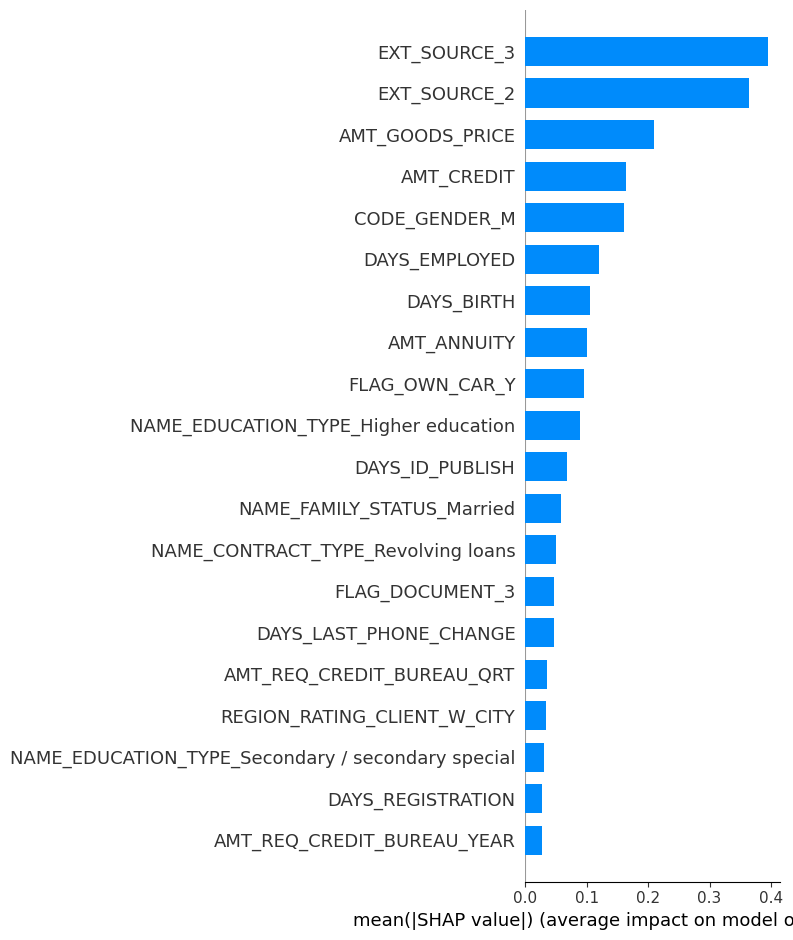

In [6]:
# STEP 4 — Global Feature Importance (Bar Plot)
shap.summary_plot(shap_values, X_test, plot_type="bar")


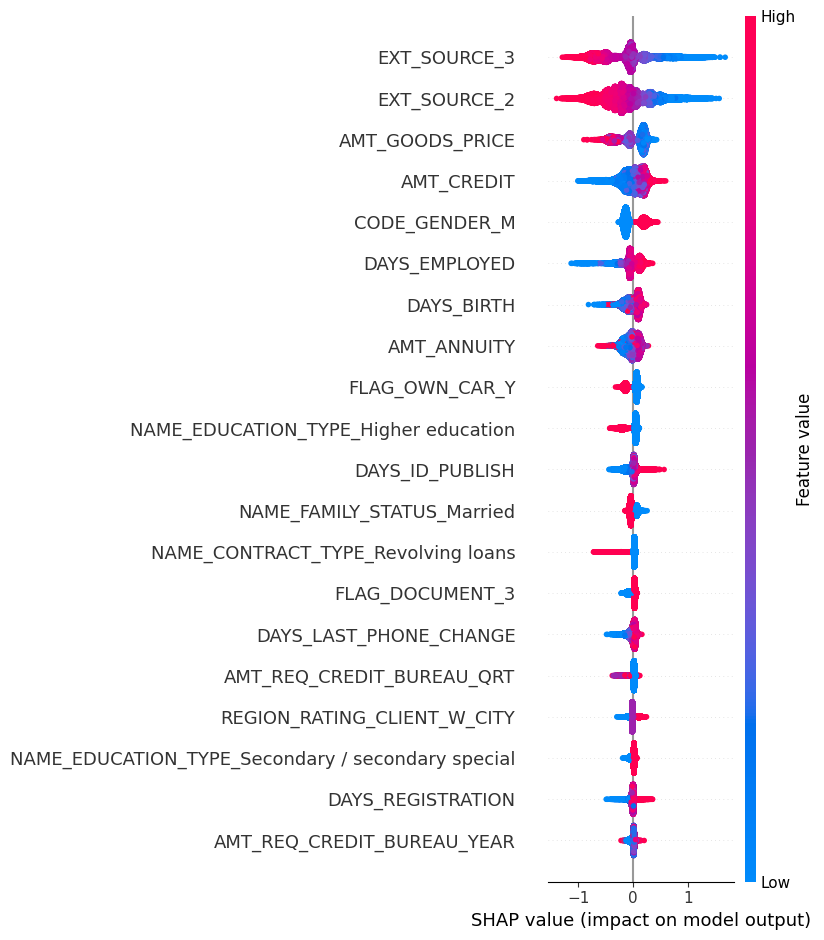

In [7]:
# SHAP Summary Plot (Detailed)
shap.summary_plot(shap_values, X_test)


#### PART 2 — Individual Customer Explanation
##### Explain one applicant:


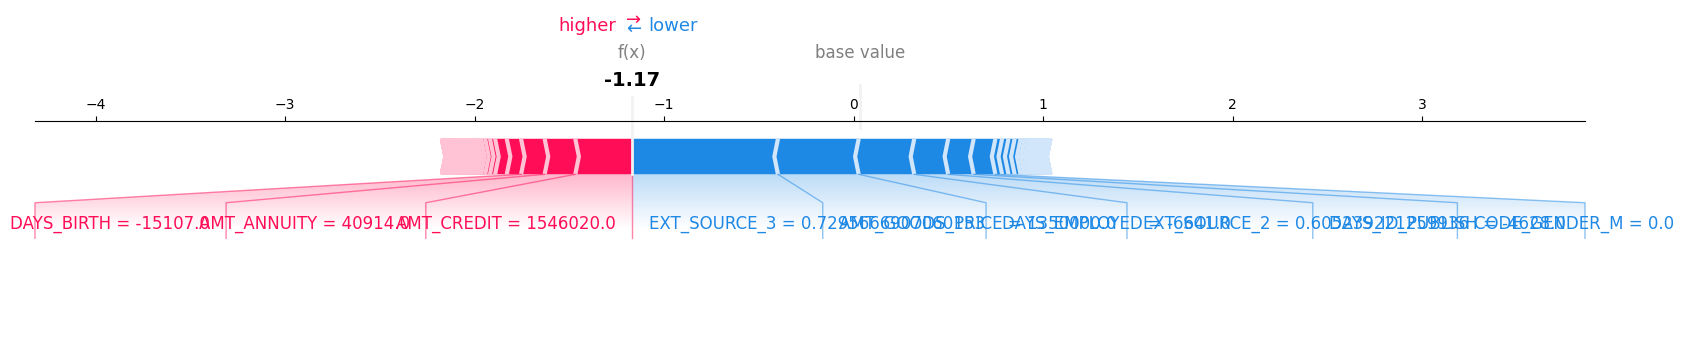

In [8]:
# Select one test sample
sample_index = 10

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index],
    matplotlib=True
)


PART 3 — LIME (Local Explainability)

LIME explains a single prediction locally.

In [9]:
# STEP 6 — Create LIME Explainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=["No Default", "Default"],
    mode="classification"
)


In [10]:
# STEP 7 — Explain Single Instance

lime_exp = lime_explainer.explain_instance(
    X_test.iloc[10].values,
    xgb_model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)


ImportError: cannot import name 'display' from 'IPython.core.display' (e:\Projects\Intelligent-Customer-Acquisition-Credit-Scorecard\venv\Lib\site-packages\IPython\core\display.py)